> 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#research-agent>

### 4. Create delegation tasks

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_core.tools import tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults 

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [3]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[get_web_search],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent",
)

In [4]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [5]:
for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "who is the mayor of NYC?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  get_web_search (d7565fb6-7e5b-46e3-9f1c-e3d703682a45)
 Call ID: d7565fb6-7e5b-46e3-9f1c-e3d703682a45
  Args:
    query: mayor of NYC



----- WEB SEARCH -----
mayor of NYC
w
1. snippet: Biographical Dictionary of American Mayors 1820-1980 (Greenwood, 1981) Short scholarly biographies of all NYC mayors 1820-1980; see list p., title: Mayor of New York City - Wikipedia, link: https://en.wikipedia.org/wiki/Mayor_of_New_York_City
2. snippet: As the mayor of New York, Bloomberg established public charter schools , rebuilt urban infrastructure, and supported gun control , public health ..., title: Michael Bloomberg - Wikipedia, link: https://en.wikipedia.org/wiki/Michael_Bloomberg
3. snippet: ... City: Mayor Adams, Acting DSNY Commissioner Lojan, DOF Commissioner Niblack Announce Automatic Rebates to Qualified Homeowners for Purchase of NYC ..., title: 

In [6]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

In [7]:
for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "what's (3 + 5) x 7"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (b5edd9c8-5191-4b4f-b1de-750d7679676b)
 Call ID: b5edd9c8-5191-4b4f-b1de-750d7679676b
  Args:
    b: 5
    a: 3


Update from node tools:


================================= Tool Message =================================
Name: add

8.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (fc8d68fa-2778-43c9-b335-623a15dfc1d4)
 Call ID: fc8d68fa-2778-43c9-b335-623a15dfc1d4
  Args:
    b: 7
    a: 8


Update from node tools:


================================= Tool Message =================================
Name: multiply

56.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent

56




In [8]:
from typing import Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.types import Command
from langgraph.types import Send


def create_task_description_handoff_tool(
    *, agent_name: str, description: str | None = None
):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help."

    @tool(name, description=description)
    def handoff_tool(
        # this is populated by the supervisor LLM
        task_description: Annotated[
            str,
            "Description of what the next agent should do, including all of the relevant context.",
        ],
        # these parameters are ignored by the LLM
        state: Annotated[MessagesState, InjectedState],
    ) -> Command:
        task_description_message = {"role": "user", "content": task_description}
        agent_input = {**state, "messages": [task_description_message]}
        return Command(
            goto=[Send(agent_name, agent_input)],
            graph=Command.PARENT,
        )

    return handoff_tool


assign_to_research_agent_with_description = create_task_description_handoff_tool(
    agent_name="research_agent",
    description="Assign task to a researcher agent.",
)

assign_to_math_agent_with_description = create_task_description_handoff_tool(
    agent_name="math_agent",
    description="Assign task to a math agent.",
)

supervisor_agent_with_description = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[
        assign_to_research_agent_with_description,
        assign_to_math_agent_with_description,
    ],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this assistant\n"
        "- a math agent. Assign math-related tasks to this assistant\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    name="supervisor",
)

supervisor_with_description = (
    StateGraph(MessagesState)
    .add_node(
        supervisor_agent_with_description, destinations=("research_agent", "math_agent")
    )
    .add_node(research_agent)
    .add_node(math_agent)
    .add_edge(START, "supervisor")
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

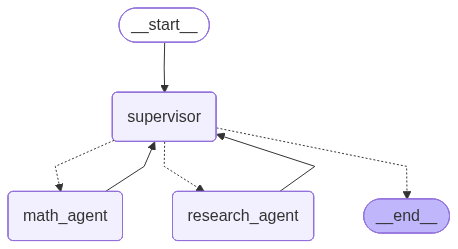

In [9]:
from IPython.display import display, Image

display(Image(supervisor_with_description.get_graph().draw_mermaid_png()))

In [10]:
for chunk in supervisor_with_description.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

Update from subgraph supervisor:


	Update from node agent:


	================================== Ai Message ==================================
	Name: supervisor
	Tool Calls:
	  transfer_to_research_agent (cfd3bf3e-ae1f-47ec-b96f-8050820364a2)
	 Call ID: cfd3bf3e-ae1f-47ec-b96f-8050820364a2
	  Args:
	    task_description: Find the projected US GDP for 2024 and the projected New York State GDP for 2024.


Update from subgraph research_agent:


	Update from node agent:


	================================== Ai Message ==================================
	Name: research_agent
	Tool Calls:
	  get_web_search (05d189d6-3956-488d-bb4a-f5b147ae472b)
	 Call ID: 05d189d6-3956-488d-bb4a-f5b147ae472b
	  Args:
	    query: projected US GDP 2024
	  get_web_search (63748489-3c55-464f-8820-d8ca735efe73)
	 Call ID: 63748489-3c55-464f-8820-d8ca735efe73
	  Args:
	    query: projected New York State GDP 2024



----- WEB SEARCH -----
projected US GDP 2024
w

----- WEB SEARCH -----
projected New York State GD